# 02 — Titanic Machine Learning

This notebook loads **only** `analytics/titanic.csv` (created by `01_eda.ipynb`). It does not call `sns.load_dataset`.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

BASE = Path(".").resolve()
ANALYTICS = BASE / "analytics" if (BASE / "analytics").exists() else BASE
CHARTS = ANALYTICS / "outputs" / "charts"
METRICS = ANALYTICS / "outputs" / "metrics"
MODELS = ANALYTICS / "models"
CHARTS.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ANALYTICS / "titanic.csv")
print("Loaded", ANALYTICS / "titanic.csv", "shape=", df.shape)
df.head()


Loaded C:\Users\vleel\OneDrive\Desktop\iitp\zepto-data-ai-platform\analytics\titanic.csv shape= (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. Stratified train/test split first

The same split is reused for Logistic Regression, Decision Tree, and Random Forest. Preprocessing is fitted on training data only.

In [2]:
target = "survived"
feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
model_df = df[feature_cols + [target]].copy()

X = model_df[feature_cols]
y = model_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train survival rate:", y_train.mean(), "Test survival rate:", y_test.mean())


Train shape: (712, 7) Test shape: (179, 7)
Train survival rate: 0.38342696629213485 Test survival rate: 0.3854748603351955


## 2. Preprocessing pipeline

Numeric: median impute + StandardScaler. Categorical: most-frequent impute + OneHotEncoder.

In [3]:
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## 3–4. Classification models and evaluation

Logistic Regression {'model': 'Logistic Regression', 'accuracy': 0.8044692737430168, 'precision': 0.7931034482758621, 'recall': 0.6666666666666666, 'f1': 0.7244094488188977, 'roc_auc': 0.8426877470355731}
confusion matrix:
 [[98 12]
 [23 46]]


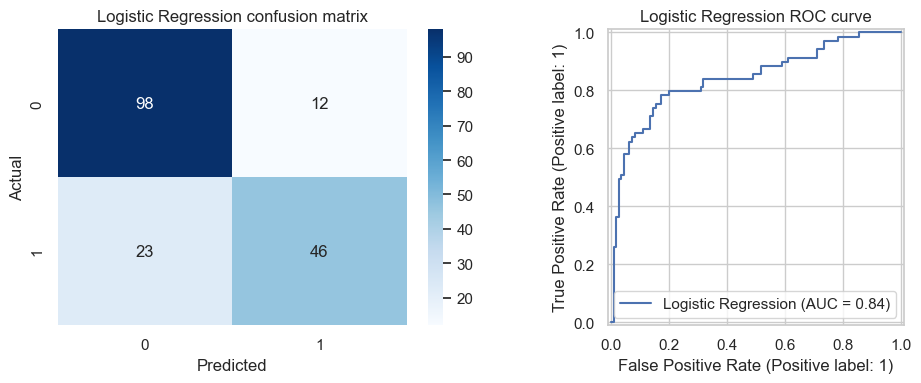

Decision Tree {'model': 'Decision Tree', 'accuracy': 0.7877094972067039, 'precision': 0.8444444444444444, 'recall': 0.5507246376811594, 'f1': 0.6666666666666666, 'roc_auc': 0.8210144927536231}
confusion matrix:
 [[103   7]
 [ 31  38]]


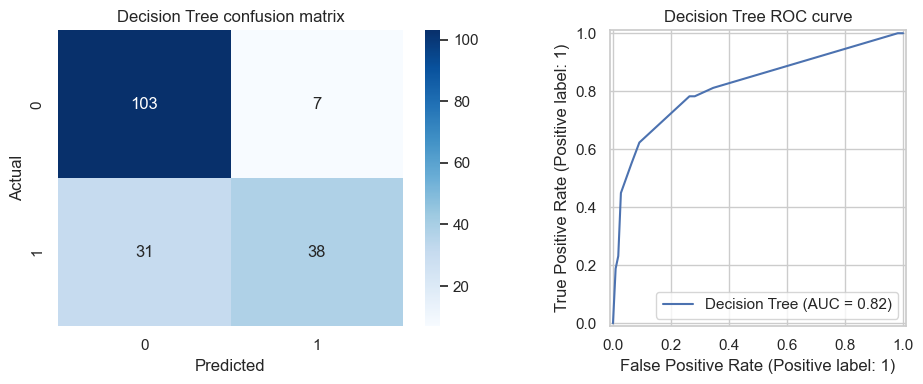

Random Forest {'model': 'Random Forest', 'accuracy': 0.8156424581005587, 'precision': 0.8103448275862069, 'recall': 0.6811594202898551, 'f1': 0.7401574803149606, 'roc_auc': 0.8306982872200264}
confusion matrix:
 [[99 11]
 [22 47]]


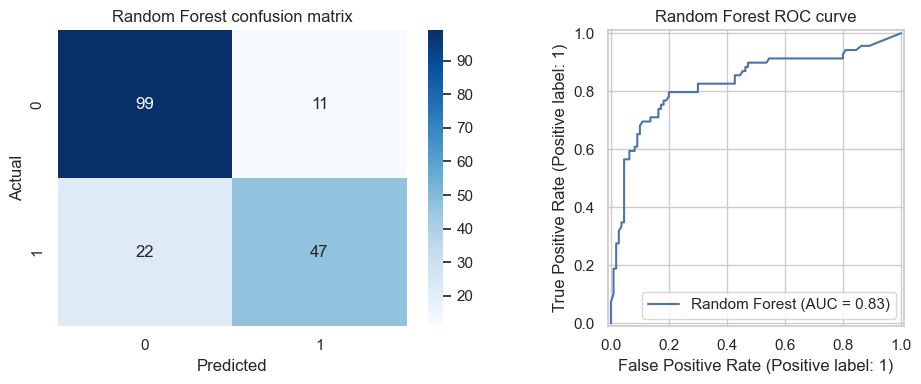

Classification comparison:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.842688
Decision Tree,0.787709,0.844444,0.550725,0.666667,0.821014
Random Forest,0.815642,0.810345,0.681159,0.740157,0.830698


In [4]:
def evaluate_classifier(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_te)[:, 1]
    else:
        y_score = pipeline.decision_function(X_te)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_score),
    }
    cm = confusion_matrix(y_te, y_pred)
    print(name, metrics)
    print("confusion matrix:\n", cm)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{name} confusion matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    RocCurveDisplay.from_predictions(y_te, y_score, ax=axes[1], name=name)
    axes[1].set_title(f"{name} ROC curve")
    fig.tight_layout()
    safe = name.lower().replace(" ", "_")
    fig.savefig(CHARTS / f"clf_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return pipeline, metrics, cm

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

fitted = {}
rows = []
for name, clf in classifiers.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    fitted[name], metrics, _ = evaluate_classifier(name, pipe, X_train, y_train, X_test, y_test)
    rows.append(metrics)

clf_table = pd.DataFrame(rows).set_index("model")
clf_table.to_csv(METRICS / "classification_comparison.csv")
print("Classification comparison:")
clf_table


## 5. Decision tree visualization

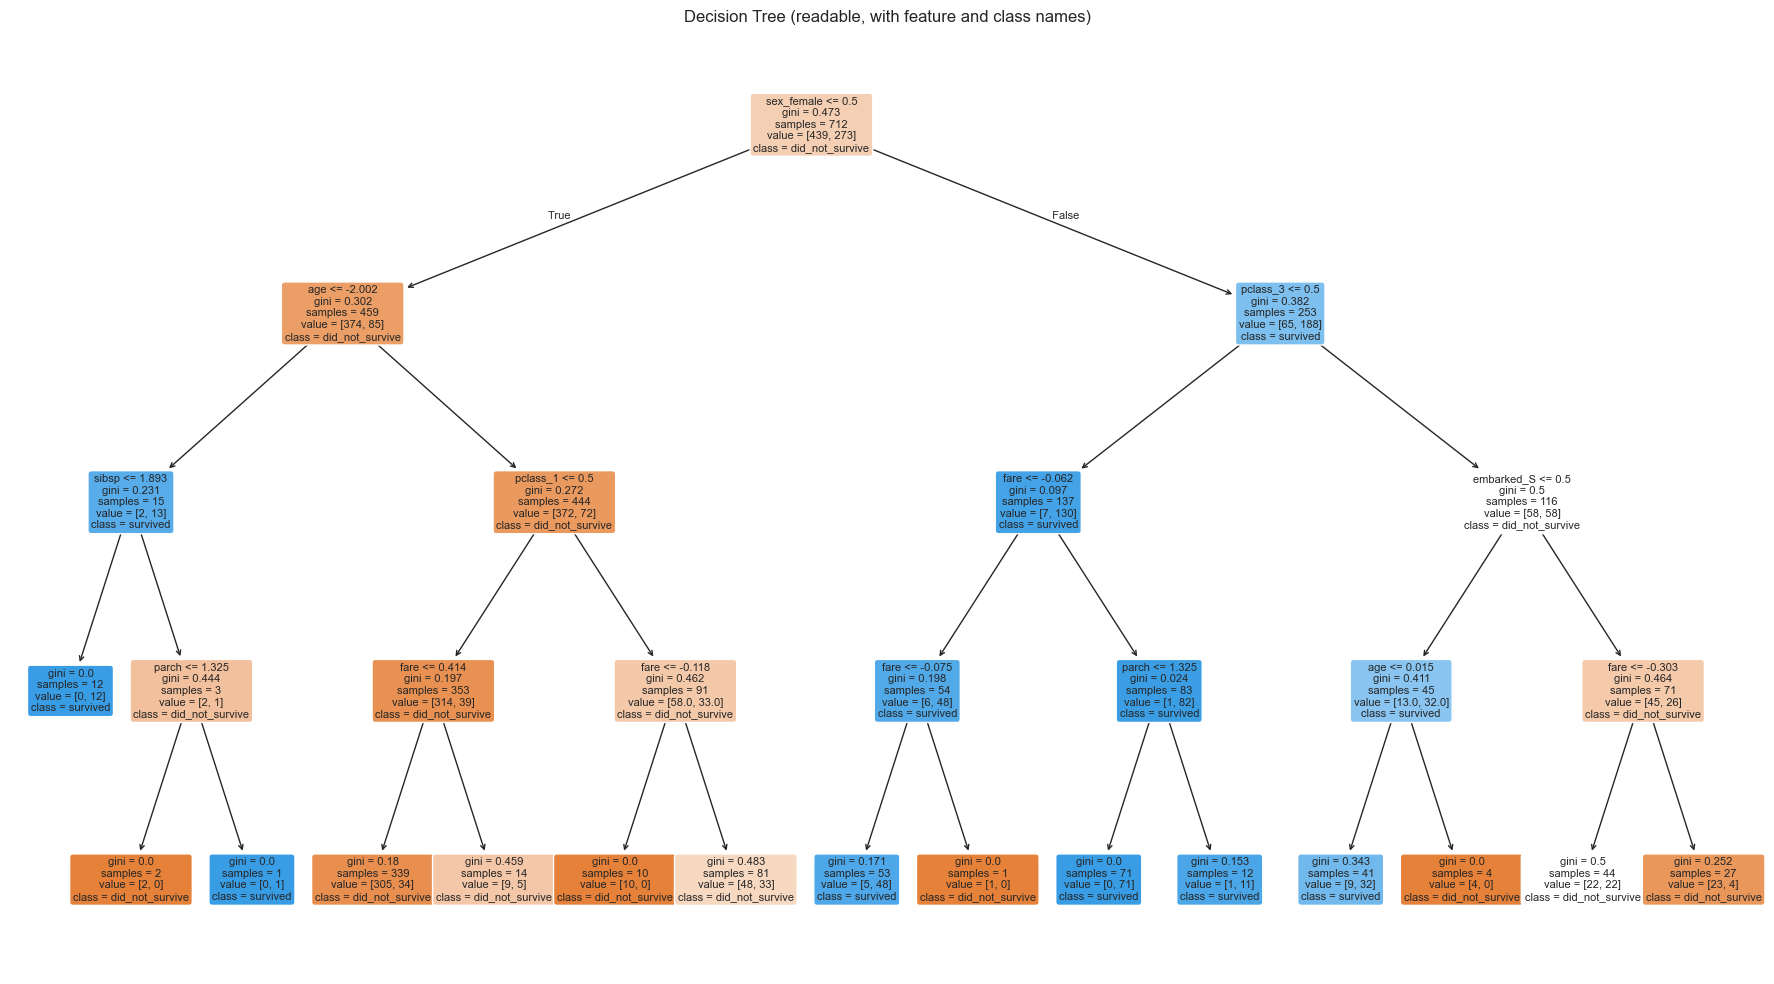

In [5]:
tree_pipe = fitted["Decision Tree"]
ohe = tree_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_names])
tree_model = tree_pipe.named_steps["model"]

fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["did_not_survive", "survived"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision Tree (readable, with feature and class names)")
fig.tight_layout()
fig.savefig(CHARTS / "decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Class imbalance comparison

A. baseline Logistic Regression  
B. `class_weight='balanced'`  
C. SMOTE applied **only** to training data (never to the test set)

In [6]:
imb_rows = []

base = Pipeline(steps=[("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000, random_state=42))])
base.fit(X_train, y_train)
yp = base.predict(X_test)
imb_rows.append({
    "method": "A_baseline",
    "precision": precision_score(y_test, yp, zero_division=0),
    "recall": recall_score(y_test, yp, zero_division=0),
    "f1": f1_score(y_test, yp, zero_division=0),
})

bal = Pipeline(steps=[("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])
bal.fit(X_train, y_train)
yp = bal.predict(X_test)
imb_rows.append({
    "method": "B_class_weight_balanced",
    "precision": precision_score(y_test, yp, zero_division=0),
    "recall": recall_score(y_test, yp, zero_division=0),
    "f1": f1_score(y_test, yp, zero_division=0),
})

# SMOTE only on transformed training features; test remains original distribution.
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_prep, y_train)
print("SMOTE train size before/after:", X_train_prep.shape, X_train_sm.shape)
print("SMOTE class counts after:", pd.Series(y_train_sm).value_counts().to_dict())

sm_clf = LogisticRegression(max_iter=1000, random_state=42)
sm_clf.fit(X_train_sm, y_train_sm)
yp = sm_clf.predict(X_test_prep)
imb_rows.append({
    "method": "C_SMOTE_train_only",
    "precision": precision_score(y_test, yp, zero_division=0),
    "recall": recall_score(y_test, yp, zero_division=0),
    "f1": f1_score(y_test, yp, zero_division=0),
})

imb_table = pd.DataFrame(imb_rows).set_index("method")
imb_table.to_csv(METRICS / "imbalance_comparison.csv")
print(imb_table)

best_imb = imb_table["f1"].idxmax()
print("Highest F1 method:", best_imb)
print(
    "Recommendation: class_weight='balanced' is usually preferable for this small tabular set "
    "because it needs no synthetic samples and still lifts recall. SMOTE can help recall further "
    "but may invent unrealistic passenger combinations. We never apply SMOTE to the test set."
)
imb_table


SMOTE train size before/after: (712, 12) (878, 12)
SMOTE class counts after: {1: 439, 0: 439}
                         precision    recall        f1
method                                                
A_baseline                0.793103  0.666667  0.724409
B_class_weight_balanced   0.739726  0.782609  0.760563
C_SMOTE_train_only        0.729730  0.782609  0.755245
Highest F1 method: B_class_weight_balanced
Recommendation: class_weight='balanced' is usually preferable for this small tabular set because it needs no synthetic samples and still lifts recall. SMOTE can help recall further but may invent unrealistic passenger combinations. We never apply SMOTE to the test set.


,precision,recall,f1
method,,,
A_baseline,0.793103,0.666667,0.724409
B_class_weight_balanced,0.739726,0.782609,0.760563
C_SMOTE_train_only,0.729730,0.782609,0.755245


## 7. Random Forest GridSearchCV and OOB score

In [7]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42)),
])
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 8],
    "model__max_features": ["sqrt", "log2"],
}
grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
X_train_prep = preprocess.fit_transform(X_train)
oob_rf = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    bootstrap=True,
    **best_params,
)
oob_rf.fit(X_train_prep, y_train)
print("OOB score:", oob_rf.oob_score_)

gs_report = {
    "best_params": grid.best_params_,
    "best_cv_f1": float(grid.best_score_),
    "oob_score": float(oob_rf.oob_score_),
}
(METRICS / "random_forest_gridsearch.json").write_text(json.dumps(gs_report, indent=2), encoding="utf-8")
gs_report


Best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV F1: 0.7514312770435932


OOB score: 0.8216292134831461


{'best_params': {'model__max_depth': 8,
  'model__max_features': 'sqrt',
  'model__n_estimators': 200},
 'best_cv_f1': 0.7514312770435932,
 'oob_score': 0.8216292134831461}

## 8. Regression task — predict fare

{'MAE': 15.373904529076626, 'RMSE': 41.07442075147528, 'R2': -0.09026479710872182, 'Adj_R2': -0.1348955197973829}


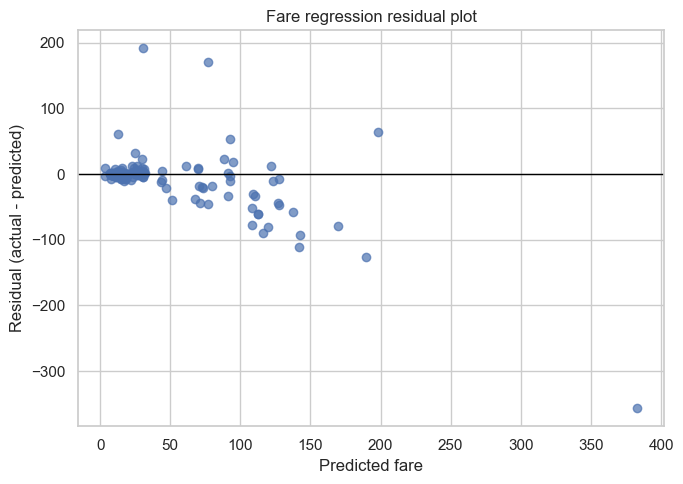

Residual std below median prediction=7.015, above=56.756
There is evidence of heteroscedasticity: residual spread grows with predicted fare.


In [8]:
reg_features = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]
reg_df = df[reg_features + ["fare"]].copy()
X_reg = reg_df[reg_features]
y_reg = reg_df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_num = ["age", "sibsp", "parch", "survived"]
reg_cat = ["pclass", "sex", "embarked"]
reg_pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), reg_cat),
    ]
)
reg_pipe = Pipeline([("preprocess", reg_pre), ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5
r2 = r2_score(yr_test, yr_pred)
n = len(yr_test)
p = Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
reg_metrics = {"MAE": mae, "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2}
print(reg_metrics)
pd.Series(reg_metrics).to_csv(METRICS / "regression_fare_metrics.csv")

residuals = yr_test - yr_pred
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(yr_pred, residuals, alpha=0.7)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Predicted fare")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Fare regression residual plot")
fig.tight_layout()
fig.savefig(CHARTS / "regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

spread_low = residuals[yr_pred <= np.median(yr_pred)].std()
spread_high = residuals[yr_pred > np.median(yr_pred)].std()
print(f"Residual std below median prediction={spread_low:.3f}, above={spread_high:.3f}")
if spread_high > 1.3 * spread_low:
    print("There is evidence of heteroscedasticity: residual spread grows with predicted fare.")
else:
    print("Residual spread is relatively stable; strong heteroscedasticity is not obvious from this split.")


## 9. Final comparison and recommendation

In [9]:
print("CLASSIFICATION METRICS")
print(clf_table)
print("\nREGRESSION METRICS (fare)")
print(pd.Series(reg_metrics))

best_clf = clf_table["f1"].idxmax()
print("\nFinal recommendation:")
print(
    f"Prefer {best_clf} as the production classifier because it has the strongest F1 "
    f"({clf_table.loc[best_clf, 'f1']:.3f}) on the held-out stratified test set, "
    f"with ROC-AUC {clf_table.loc[best_clf, 'roc_auc']:.3f}. "
    "Logistic Regression remains the most interpretable linear baseline, and the Decision Tree "
    "is useful for explaining rules, but ensemble averaging usually generalizes better on Titanic. "
    "The fare regressor is a separate task and should not be chosen using classification metrics."
)


CLASSIFICATION METRICS
                     accuracy  precision    recall        f1   roc_auc
model                                                                 
Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.842688
Decision Tree        0.787709   0.844444  0.550725  0.666667  0.821014
Random Forest        0.815642   0.810345  0.681159  0.740157  0.830698

REGRESSION METRICS (fare)
MAE       15.373905
RMSE      41.074421
R2        -0.090265
Adj_R2    -0.134896
dtype: float64

Final recommendation:
Prefer Random Forest as the production classifier because it has the strongest F1 (0.740) on the held-out stratified test set, with ROC-AUC 0.831. Logistic Regression remains the most interpretable linear baseline, and the Decision Tree is useful for explaining rules, but ensemble averaging usually generalizes better on Titanic. The fare regressor is a separate task and should not be chosen using classification metrics.


## 10. Save complete pipeline, reload, and predict on RAW rows

In [10]:
best_name = clf_table["f1"].idxmax()
best_pipeline = fitted[best_name]
out_path = MODELS / "best_pipeline.joblib"
joblib.dump(best_pipeline, out_path)
print("Saved", out_path, "model=", best_name)

reloaded = joblib.load(out_path)
raw_input = pd.DataFrame([
    {
        "pclass": 3,
        "sex": "male",
        "age": 22,
        "sibsp": 1,
        "parch": 0,
        "fare": 7.25,
        "embarked": "S",
    },
    {
        "pclass": 1,
        "sex": "female",
        "age": 38,
        "sibsp": 1,
        "parch": 0,
        "fare": 71.2833,
        "embarked": "C",
    },
])
print("RAW unprocessed input:")
print(raw_input)
print("Reloaded pipeline predictions:", reloaded.predict(raw_input))
print("Reloaded pipeline probabilities:\n", reloaded.predict_proba(raw_input))


Saved C:\Users\vleel\OneDrive\Desktop\iitp\zepto-data-ai-platform\analytics\models\best_pipeline.joblib model= Random Forest


RAW unprocessed input:
   pclass     sex  age  sibsp  parch     fare embarked
0       3    male   22      1      0   7.2500        S
1       1  female   38      1      0  71.2833        C
Reloaded pipeline predictions: [0 1]


Reloaded pipeline probabilities:
 [[0.88 0.12]
 [0.   1.  ]]
